# Experiment Notebook
This note will perform the following :
* Load TypiClust Selections
* Generate random selections
* Train ResNet-18
* Save Results 
* Generate Diagrams 
* Perform statistical analysis - entailing, Paired t-tests, Confidence Intervals and Effect Sizes

In [1]:
import os 
import numpy as np
import torch 
import torchvision
import random 

# Graphical concerns below
import matplotlib.pyplot as plt
import seaborn as sns 
import pandas as pd 
from tqdm import tqdm  # Loading visualiser.

from supervised_training import train_supervised




In [5]:
# Reproducibility measures
torch.manual_seed(0)
np.random.seed(0)
random.seed(0)

# budgets matching the paper 
budgets = [10,20,40,80]
seeds= [0,1,2,3,4] # Statistical Inference

In [6]:
typiclust_selections = {
    B: np.load(f"../TPCRP_Algorithm/budget_results/typiclust_B{B}.npy")
    for B in budgets
}


In [7]:
random_selections = {}

for seed in seeds:
    np.random.seed(seed)
    random_selections[seed] = {
        B: np.random.choice(50000, size=B, replace=False)
        for B in budgets
    }


In [8]:
os.makedirs("results/accuracies", exist_ok=True)
os.makedirs("results/loss_curves", exist_ok=True)
os.makedirs("results/runtimes", exist_ok=True)


In [9]:
results = []

for seed in seeds:
    torch.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)

    for B in budgets:

        # --- TypiClust ---
        typi_idx = typiclust_selections[B]
        acc, loss_curve, runtime = train_supervised(
            selected_indices=typi_idx,
            epochs=50,          # reduced for compute constraints
            batch_size=128,
            lr=0.1,
            momentum=0.9,
            weight_decay=5e-4
        )

        results.append({
            "method": "TypiClust",
            "budget": B,
            "seed": seed,
            "accuracy": acc,
            "runtime": runtime
        })

        # Save loss curve
        np.save(f"results/loss_curves/typiclust_B{B}_seed{seed}.npy", np.array(loss_curve))

        # --- Random ---
        rand_idx = random_selections[seed][B]
        acc, loss_curve, runtime = train_supervised(
            selected_indices=rand_idx,
            epochs=50,
            batch_size=128,
            lr=0.1,
            momentum=0.9,
            weight_decay=5e-4
        )

        results.append({
            "method": "Random",
            "budget": B,
            "seed": seed,
            "accuracy": acc,
            "runtime": runtime
        })

        np.save(f"results/loss_curves/random_B{B}_seed{seed}.npy", np.array(loss_curve))


# CSV Offloading 
df = pd.DataFrame(results)
df.to_csv("results/accuracies/all_results.csv", index=False)
df


100%|██████████| 170M/170M [00:07<00:00, 23.3MB/s] 
/home/ariag/5CCSAMLF/second_coursework/env/lib/python3.12/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


 Epoch 1/50 :::  Loss 2.9435
 Epoch 2/50 :::  Loss 4.8124
 Epoch 3/50 :::  Loss 12.7674
 Epoch 4/50 :::  Loss 11.6934
 Epoch 5/50 :::  Loss 4.2148
 Epoch 6/50 :::  Loss 3.5372
 Epoch 7/50 :::  Loss 2.9575
 Epoch 8/50 :::  Loss 1.7616
 Epoch 9/50 :::  Loss 1.2055
 Epoch 10/50 :::  Loss 0.6826
 Epoch 11/50 :::  Loss 0.5069
 Epoch 12/50 :::  Loss 0.5139
 Epoch 13/50 :::  Loss 1.0632
 Epoch 14/50 :::  Loss 1.5091
 Epoch 15/50 :::  Loss 0.3611
 Epoch 16/50 :::  Loss 0.6917
 Epoch 17/50 :::  Loss 0.6766
 Epoch 18/50 :::  Loss 1.0800
 Epoch 19/50 :::  Loss 0.6294
 Epoch 20/50 :::  Loss 0.4380
 Epoch 21/50 :::  Loss 0.2881
 Epoch 22/50 :::  Loss 0.2442
 Epoch 23/50 :::  Loss 0.3161
 Epoch 24/50 :::  Loss 0.3321
 Epoch 25/50 :::  Loss 0.3199
 Epoch 26/50 :::  Loss 0.4197
 Epoch 27/50 :::  Loss 0.2142
 Epoch 28/50 :::  Loss 0.2959
 Epoch 29/50 :::  Loss 0.2580
 Epoch 30/50 :::  Loss 0.2059
 Epoch 31/50 :::  Loss 0.2779
 Epoch 32/50 :::  Loss 0.2078
 Epoch 33/50 :::  Loss 0.6525
 Epoch 34/50 ::: 

,method,budget,seed,accuracy,runtime
0,TypiClust,10,0,0.1127,4.535907
1,Random,10,0,0.1290,4.668597
2,TypiClust,20,0,0.1097,4.938298
3,Random,20,0,0.1336,4.977836
4,TypiClust,40,0,0.2108,6.318038
5,Random,40,0,0.1340,5.698260
6,TypiClust,80,0,0.2417,6.597294
7,Random,80,0,0.1963,6.628721
8,TypiClust,10,1,0.1088,5.441088
9,Random,10,1,0.1562,4.685789


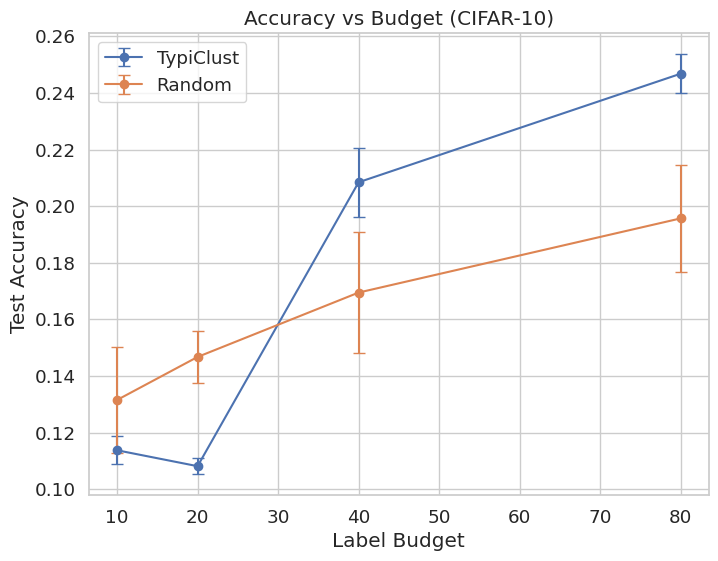

In [10]:
plt.figure(figsize=(8,6))
sns.set(style="whitegrid", font_scale=1.2)

for method in ["TypiClust", "Random"]:
    means = []
    stds = []
    for B in budgets:
        subset = df[(df.method == method) & (df.budget == B)]
        means.append(subset.accuracy.mean())
        stds.append(subset.accuracy.std())

    plt.errorbar(budgets, means, yerr=stds, marker='o', capsize=4, label=method)


os.makedirs("results/plots", exist_ok=True)

plt.xlabel("Label Budget")
plt.ylabel("Test Accuracy")
plt.title("Accuracy vs Budget (CIFAR-10)")
plt.legend()
plt.savefig("results/plots/accuracy_vs_budget.png", dpi=300)
plt.show()


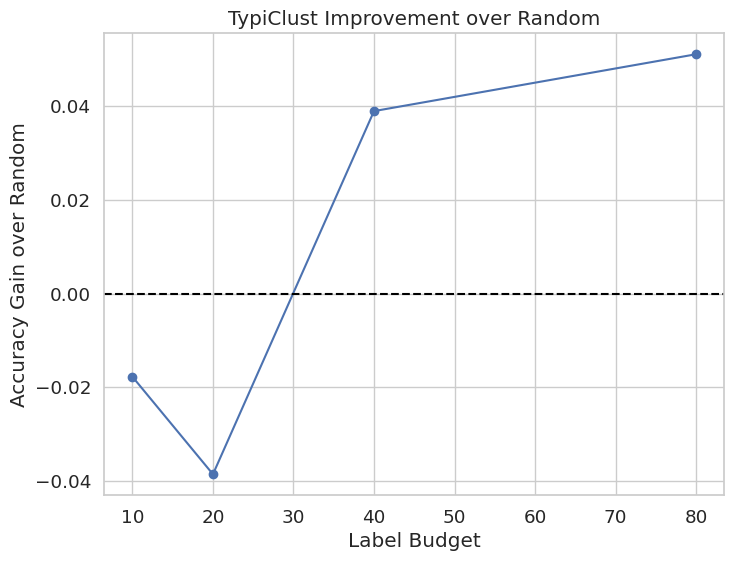

In [11]:
plt.figure(figsize=(8,6))

gain = []
for B in budgets:
    t = df[(df.method=="TypiClust") & (df.budget==B)].accuracy.mean()
    r = df[(df.method=="Random") & (df.budget==B)].accuracy.mean()
    gain.append(t - r)

plt.plot(budgets, gain, marker='o')
plt.axhline(0, color='black', linestyle='--')
plt.xlabel("Label Budget")
plt.ylabel("Accuracy Gain over Random")
plt.title("TypiClust Improvement over Random")
plt.savefig("results/plots/gain_over_random.png", dpi=300)
plt.show()


In [12]:
from scipy.stats import ttest_rel

for B in budgets:
    t = df[(df.method=="TypiClust") & (df.budget==B)].accuracy.values
    r = df[(df.method=="Random") & (df.budget==B)].accuracy.values

    stat, p = ttest_rel(t, r)
    print(f"B={B}: p-value = {p:.4e}")


B=10: p-value = 1.0323e-01
B=20: p-value = 9.9551e-04
B=40: p-value = 2.1332e-02
B=80: p-value = 2.5517e-03


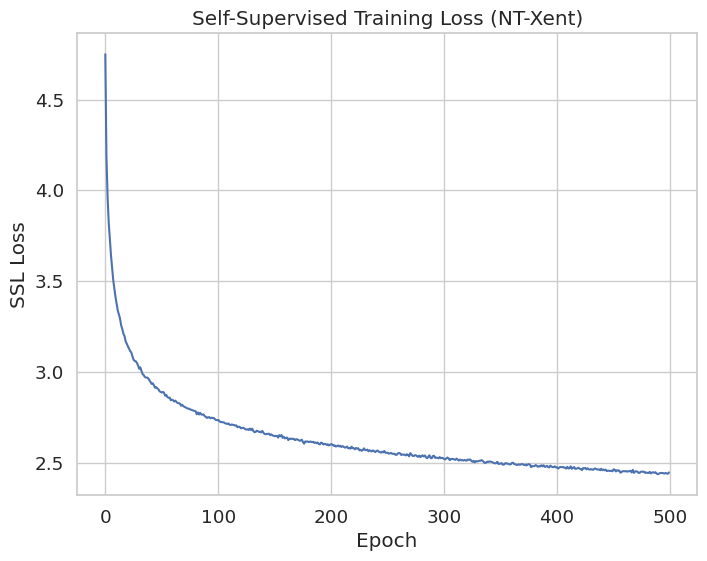

In [13]:
ssl_loss = np.load("../TPCRP_Algorithm/budget_results/ssl_loss.npy")


plt.figure(figsize=(8,6))
plt.plot(ssl_loss)
plt.xlabel("Epoch")
plt.ylabel("SSL Loss")
plt.title("Self-Supervised Training Loss (NT-Xent)")
plt.savefig("results/plots/ssl_loss_curve.png", dpi=300)
plt.show()


In [15]:
from sklearn.manifold import TSNE

# Load features from Task 1
features = np.load("../TPCRP_Algorithm/budget_results/features.npy")

tsne = TSNE(n_components=2, perplexity=30)
emb = tsne.fit_transform(features)

plt.figure(figsize=(8,8))
plt.scatter(emb[:,0], emb[:,1], s=2, alpha=0.5)
plt.title("t-SNE of SSL Features")
plt.savefig("results/plots/tsne.png", dpi=300)
plt.show()


FileNotFoundError: [Errno 2] No such file or directory: '../TPCRP_Algorithm/budget_results/features.npy'

/home/ariag/5CCSAMLF/second_coursework/env/lib/python3.12/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


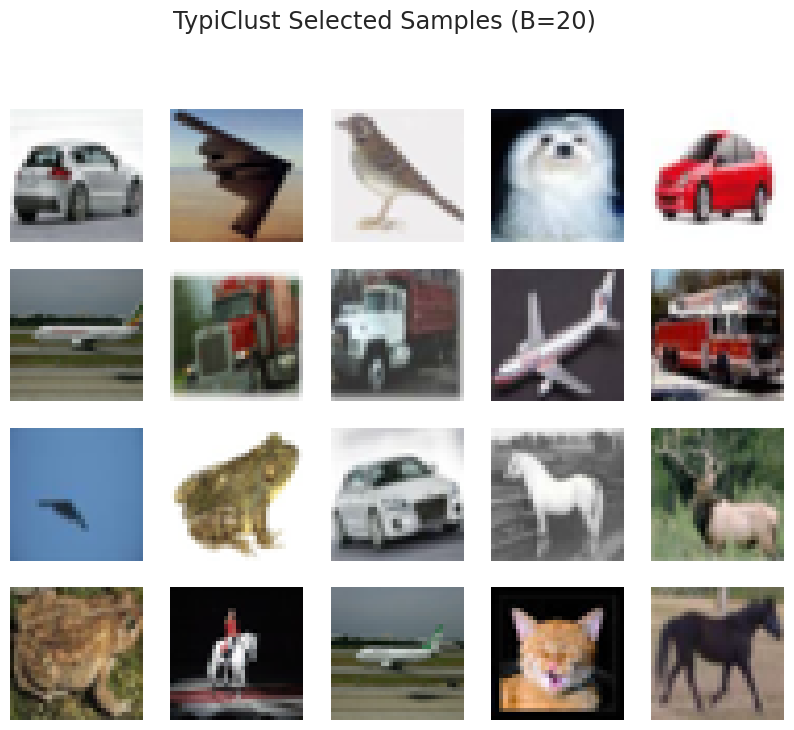

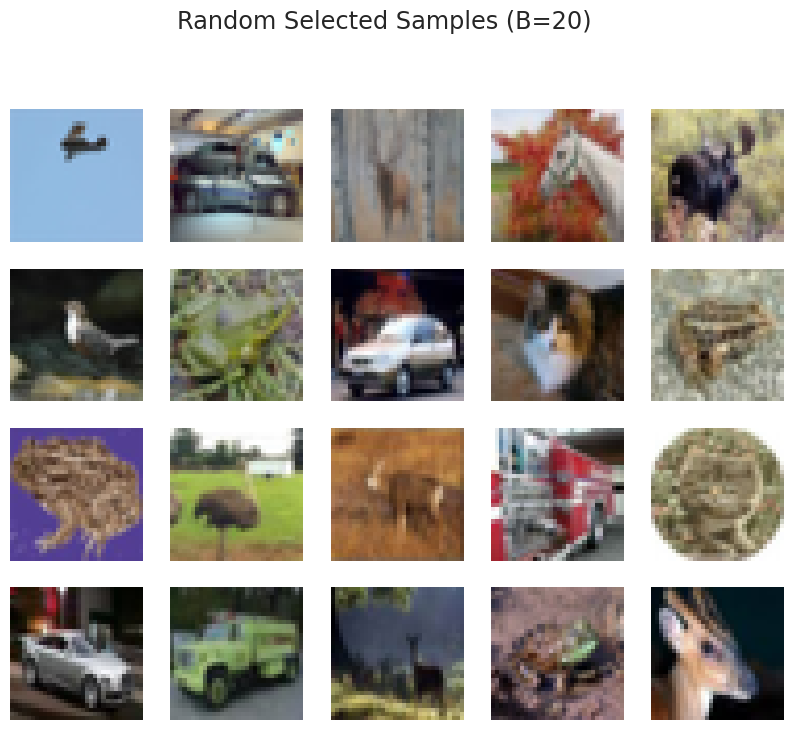

In [16]:
import matplotlib.pyplot as plt



def show_images(indices, title):
    dataset = torchvision.datasets.CIFAR10(root="./data", train=True, download=True)
    plt.figure(figsize=(10,10))
    for i, idx in enumerate(indices[:25]):
        plt.subplot(5,5,i+1)
        plt.imshow(dataset[idx][0])
        plt.axis("off")
    plt.suptitle(title)
    plt.show()

show_images(typiclust_selections[20], "TypiClust Selected Samples (B=20)")
show_images(random_selections[0][20], "Random Selected Samples (B=20)")
